# Wind Speed Forecasting — Northern Norway Stations

This notebook uses the **Aardvark Weather** model to forecast wind speed at three Norwegian coastal stations, then validates predictions against observations downloaded from the [Frost API](https://frost.met.no) (the programmatic interface to seklima.met.no).

### Target stations
| Station | Latitude | Longitude | Frost ID |
|---------|----------|-----------|----------|
| Hekkingen fyr | 69.6016 °N | 17.8298 °E | SN76920 |
| Fakken | 70.1005 °N | 20.1058 °E | SN91380 |
| Tromsø-Langnes | 69.6834 °N | 18.9168 °E | SN90450 |

### Workflow
1. Load the Aardvark model (wind-speed decoder).
2. Run inference on the bundled sample data to obtain station wind-speed forecasts.
3. Download 7-day hourly observations from the Frost API.
4. Compute accuracy metrics (RMSE, MAE, bias, Pearson r).
5. Visualise with scatter plots, time-series overlays and error histograms.

> **Note on sample data**: The bundled pickle (`sample_data_final.pkl`) covers a single analysis time-step. For a true 7-day hindcast you would supply one ERA5-derived input file per day; the code structure below is identical — just wrap Section 2 in a date loop. The validation section uses real 7-day observations regardless.

## 1 — Imports and configuration

In [2]:
import io
import sys
import os
import pickle
import warnings
from datetime import datetime, timedelta, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from scipy import stats

sys.path.append("../aardvark")
from e2e_model import ConvCNPWeatherE2E

matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore")

# All figures saved here
FIGURES_DIR = Path("wind_forecast_figures")
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Figures will be saved to: {FIGURES_DIR.resolve()}")
print("Imports OK")

/Users/siche9897/miniconda3/lib/python3.13/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Figures will be saved to: /Users/siche9897/Github/Weather-Forecasting/aardvark-weather-public-main/notebooks/wind_forecast_figures
Imports OK


In [3]:
if torch.cuda.is_available():
    device = "cuda"
    print(f"CUDA GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = "mps"
    print("Apple MPS (Metal) GPU")
else:
    device = "cpu"
    print("CPU only")

Apple MPS (Metal) GPU


## 2 — Station definitions

Coordinates are stored in two representations:
- **Physical**: degrees (lat, lon)
- **Normalised**: divided by the Aardvark scaling factor (360) so both axes live in [0, 1]

In [4]:
STATION_LON_LAT_SF = 360
HADISD_SCALING_FACTOR = 10

STATIONS = {
    "Hekkingen": {
        "lat": 69.6016,
        "lon": 17.8298,
        "frost_id": "SN88690",   # HEKKINGEN FYR  (69.6005N 17.8312E)
        "color": "#E63946",
        "marker": "o",
    },
    "Fakken": {
        "lat": 70.1005,
        "lon": 20.1058,
        "frost_id": "SN90760",   # FAKKEN  (70.1043N 20.1145E)
        "color": "#2196F3",
        "marker": "s",
    },
    "Tromsø-Langnes": {
        "lat": 69.6834,
        "lon": 18.9168,
        "frost_id": "SN90490",   # TROMSØ - LANGNES  (69.6767N 18.9133E)
        "color": "#4CAF50",
        "marker": "^",
    },
}

for name, info in STATIONS.items():
    info["norm_lon"] = info["lon"] / STATION_LON_LAT_SF
    info["norm_lat"] = info["lat"] / STATION_LON_LAT_SF

station_names = list(STATIONS.keys())
print("Station summary:")
for name, info in STATIONS.items():
    print(f"  {name:20s}  lat={info['lat']:.4f}  lon={info['lon']:.4f}  "
          f"norm=({info['norm_lon']:.5f}, {info['norm_lat']:.5f})  Frost={info['frost_id']}")

Station summary:
  Hekkingen             lat=69.6016  lon=17.8298  norm=(0.04953, 0.19334)  Frost=SN88690
  Fakken                lat=70.1005  lon=20.1058  norm=(0.05585, 0.19472)  Frost=SN90760
  Tromsø-Langnes        lat=69.6834  lon=18.9168  norm=(0.05255, 0.19357)  Frost=SN90490


## 3 — Load Aardvark sample data

In [5]:
class CPU_Unpickler(pickle.Unpickler):
    """Load pickles that contain CUDA tensors onto CPU."""
    def find_class(self, module, name):
        if module == "torch.storage" and name == "_load_from_bytes":
            return lambda b: torch.load(io.BytesIO(b), map_location="cpu")
        return super().find_class(module, name)


def move_to_device(obj, device):
    if isinstance(obj, torch.Tensor):
        return obj.to(device)
    elif isinstance(obj, dict):
        return {k: move_to_device(v, device) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [move_to_device(v, device) for v in obj]
    elif isinstance(obj, tuple):
        return tuple(move_to_device(v, device) for v in obj)
    return obj


data_path = "../data/sample_data_final.pkl"
with open(data_path, "rb") as fp:
    data = CPU_Unpickler(fp).load()

data = move_to_device(data, device)
print("Sample data loaded.")
print(f"Top-level keys: {list(data.keys())}")
print(f"Downscaling keys: {list(data['downscaling'].keys())}")
print(f"n_stations in sample data: {data['downscaling']['x_target'].shape[-1]}")

Sample data loaded.
Top-level keys: ['assimilation', 'forecast', 'downscaling', 'y_target']
Downscaling keys: ['x_target', 'alt_target', 'y_target', 'y_context', 'x_context', 'aux_time', 'lt']
n_stations in sample data: 8719


In [6]:
# Inspect the geographic extent of HadISD stations in the sample
all_lons = data["downscaling"]["x_target"][0, 0, :].detach().cpu().numpy() * STATION_LON_LAT_SF
all_lats = data["downscaling"]["x_target"][0, 1, :].detach().cpu().numpy() * STATION_LON_LAT_SF

print(f"Station lon range: [{all_lons.min():.1f}, {all_lons.max():.1f}]")
print(f"Station lat range: [{all_lats.min():.1f}, {all_lats.max():.1f}]")

# Find existing stations in the sample closest to our 3 target stations
print("\nNearest HadISD stations in sample data to our targets:")
for name, info in STATIONS.items():
    dists = np.sqrt((all_lons - info["lon"])**2 + (all_lats - info["lat"])**2)
    idx = np.argmin(dists)
    info["nearest_idx"] = idx
    info["nearest_dist_deg"] = dists[idx]
    print(f"  {name:20s} → index {idx:5d}  "
          f"lat={all_lats[idx]:.3f}  lon={all_lons[idx]:.3f}  "
          f"dist={dists[idx]:.3f}°")

Station lon range: [0.0, 360.0]
Station lat range: [-89.0, 83.7]

Nearest HadISD stations in sample data to our targets:
  Hekkingen            → index     6  lat=69.600  lon=17.833  dist=0.004°
  Fakken               → index    12  lat=70.250  lon=19.500  dist=0.624°
  Tromsø-Langnes       → index     8  lat=69.683  lon=18.919  dist=0.002°


## 4 — Load wind-speed model and run inference

We use the `ws` (wind speed) decoder. The model pipeline is:
- **Encoder** — assimilates satellite + synoptic observations → gridded state
- **Processor** — autoregressive 24-h rollout
- **Decoder** — UNet downscaling → station predictions

In [7]:
local_forecast_var = "ws"  # Wind speed

model = ConvCNPWeatherE2E(
    device=device,
    lead_time=1,
    se_model_path="../trained_models/encoder",
    forecast_model_path="../trained_models/processor",
    sf_model_path=f"../trained_models/decoder/{local_forecast_var}/",
    return_gridded=True,
    aux_data_path="../data/",
)

print("Model loaded.")

Model loaded.


In [8]:
# Single-step inference (lead_time=1) with gridded output — used for the global map
with torch.no_grad():
    station_forecast_raw, global_forecast, initial_state = model(data)

print(f"station_forecast shape : {station_forecast_raw.shape}")
print(f"global_forecast shape  : {global_forecast.shape}")
print(f"initial_state shape    : {initial_state.shape}")

station_forecast shape : torch.Size([1, 8719])
global_forecast shape  : torch.Size([1, 121, 240, 24])
initial_state shape    : torch.Size([1, 121, 240, 24])


In [9]:
# Load HadISD normalisation factors for wind speed
mean_ws = np.load(f"../data/norm_factors/mean_hadisd_{local_forecast_var}.npy")
std_ws  = np.load(f"../data/norm_factors/std_hadisd_{local_forecast_var}.npy")

print(f"HadISD ws mean: {mean_ws:.4f}   std: {std_ws:.4f}")

# Denormalise: reverse z-score then multiply by HadISD scale factor → m/s
station_forecast_all = (
    station_forecast_raw.detach().cpu().numpy() * std_ws + mean_ws
) * HADISD_SCALING_FACTOR

# Clip negative predictions (wind speed must be ≥ 0)
station_forecast_all = np.clip(station_forecast_all, 0, None)

p_flat = station_forecast_all[0]  # shape (n_stations,)

print(f"\nModel wind speed predictions — all {len(p_flat)} stations:")
print(f"  min={p_flat.min():.2f}  mean={p_flat.mean():.2f}  max={p_flat.max():.2f} m/s")

# Note: y_target in the sample data is NaN for the ws variable (masked ground truth).
# Validation is done against the Frost API observations downloaded in Section 6.

HadISD ws mean: 0.3394   std: 0.2996

Model wind speed predictions — all 8719 stations:
  min=0.00  mean=3.51  max=26.29 m/s


In [10]:
## 4b — Build 7-day forecast trajectory (lead_time = 1 … 7)
#
# The Aardvark processor is autoregressive: running with lead_time=N produces
# the N-day-ahead forecast from the same initial observation state.
# Running 7 separate forward passes gives a forecast trajectory:
#   day+1, day+2, …, day+7
# Each station gets a different value at each lead time → truly dynamic.

FORECAST_DAYS = 7

print(f"Running {FORECAST_DAYS} forward passes (lead_time 1 … {FORECAST_DAYS}) …")
# Initialise trajectory dict
trajectory = {name: [] for name in STATIONS}

for lt in range(1, FORECAST_DAYS + 1):
    m_lt = ConvCNPWeatherE2E(
        device=device,
        lead_time=lt,
        se_model_path="../trained_models/encoder",
        forecast_model_path="../trained_models/processor",
        sf_model_path=f"../trained_models/decoder/{local_forecast_var}/",
        return_gridded=False,
        aux_data_path="../data/",
    )
    with torch.no_grad():
        sf_lt = m_lt(data)
    sf_np = np.clip(
        (sf_lt.detach().cpu().numpy() * std_ws + mean_ws) * HADISD_SCALING_FACTOR,
        0, None
    )
    row_parts = []
    for name, info in STATIONS.items():
        val = float(sf_np[0, info["nearest_idx"]])
        trajectory[name].append(val)
        row_parts.append(f"{name}={val:.2f}")
    print(f"  day+{lt}: " + "  ".join(row_parts))

# Convert to arrays
for name in STATIONS:
    STATIONS[name]["forecast_trajectory"] = np.array(trajectory[name])  # shape (7,)

print("\nTrajectory built. Values (m/s):")
print(f"{'Day':>5s} | " + " | ".join(f"{n:>15s}" for n in STATIONS))
print("-" * (8 + 19 * len(STATIONS)))
for d in range(FORECAST_DAYS):
    row = " | ".join(f"{STATIONS[n]['forecast_trajectory'][d]:>15.2f}" for n in STATIONS)
    print(f"  +{d+1:2d}  | {row}")

Running 7 forward passes (lead_time 1 … 7) …
  day+1: Hekkingen=2.29  Fakken=4.37  Tromsø-Langnes=3.99
  day+2: Hekkingen=3.48  Fakken=6.97  Tromsø-Langnes=2.95
  day+3: Hekkingen=3.40  Fakken=8.23  Tromsø-Langnes=5.41
  day+4: Hekkingen=4.77  Fakken=3.58  Tromsø-Langnes=3.89
  day+5: Hekkingen=1.96  Fakken=4.29  Tromsø-Langnes=3.16
  day+6: Hekkingen=2.29  Fakken=3.45  Tromsø-Langnes=1.45
  day+7: Hekkingen=3.40  Fakken=3.73  Tromsø-Langnes=2.62

Trajectory built. Values (m/s):
  Day |       Hekkingen |          Fakken |  Tromsø-Langnes
-----------------------------------------------------------------
  + 1  |            2.29 |            4.37 |            3.99
  + 2  |            3.48 |            6.97 |            2.95
  + 3  |            3.40 |            8.23 |            5.41
  + 4  |            4.77 |            3.58 |            3.89
  + 5  |            1.96 |            4.29 |            3.16
  + 6  |            2.29 |            3.45 |            1.45
  + 7  |            3.40

In [11]:
# Use day+1 as the representative single-step forecast for map & metrics
for name, info in STATIONS.items():
    info["sample_pred"] = info["forecast_trajectory"][0]  # day+1

print("Day+1 Aardvark forecast at target stations:")
print(f"{'Station':20s}  {'Forecast (m/s)':>14s}")
print("-" * 38)
for name, info in STATIONS.items():
    print(f"{name:20s}  {info['sample_pred']:>14.2f}")

Day+1 Aardvark forecast at target stations:
Station               Forecast (m/s)
--------------------------------------
Hekkingen                       2.29
Fakken                          4.37
Tromsø-Langnes                  3.99


## 5 — Visualise: station map and global wind field

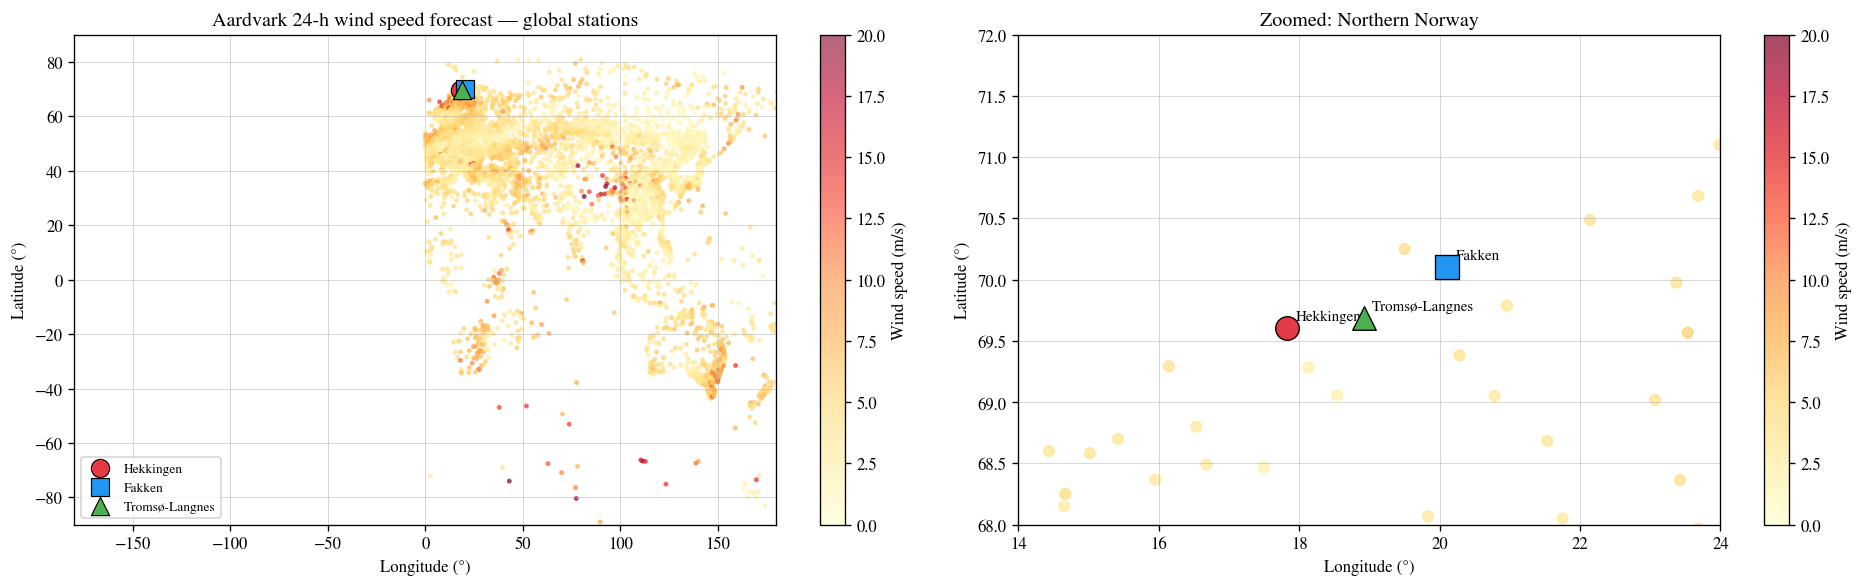

Saved → wind_forecast_figures/wind_forecast_map.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: all HadISD station predictions (scatter on map) ---
ax = axes[0]
sc = ax.scatter(
    all_lons, all_lats,
    c=p_flat,
    cmap="YlOrRd", vmin=0, vmax=20,
    s=4, alpha=0.6, rasterized=True,
)
plt.colorbar(sc, ax=ax, label="Wind speed (m/s)")
for name, info in STATIONS.items():
    ax.scatter(info["lon"], info["lat"],
               color=info["color"], marker=info["marker"],
               s=120, zorder=5, edgecolors="k", linewidths=0.7,
               label=name)
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("Aardvark 24-h wind speed forecast — global stations")
ax.legend(fontsize=8, loc="lower left")
ax.grid(True, linewidth=0.3)

# --- Right: zoomed Northern Norway ---
ax = axes[1]
region_mask = (all_lons > 10) & (all_lons < 30) & (all_lats > 65) & (all_lats < 72)
if region_mask.sum() > 0:
    sc2 = ax.scatter(
        all_lons[region_mask], all_lats[region_mask],
        c=p_flat[region_mask],
        cmap="YlOrRd", vmin=0, vmax=20,
        s=40, alpha=0.7,
    )
    plt.colorbar(sc2, ax=ax, label="Wind speed (m/s)")
for name, info in STATIONS.items():
    ax.scatter(info["lon"], info["lat"],
               color=info["color"], marker=info["marker"],
               s=200, zorder=5, edgecolors="k", linewidths=0.8)
    ax.annotate(name, xy=(info["lon"], info["lat"]),
                xytext=(5, 5), textcoords="offset points", fontsize=9)
ax.set_xlim(14, 24)
ax.set_ylim(68, 72)
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("Zoomed: Northern Norway")
ax.grid(True, linewidth=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "wind_forecast_map.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'wind_forecast_map.png'}")

### Global wind-component fields

Visualise the 10-m zonal (`u10`) and meridional (`v10`) components and compute total wind speed on the global grid.

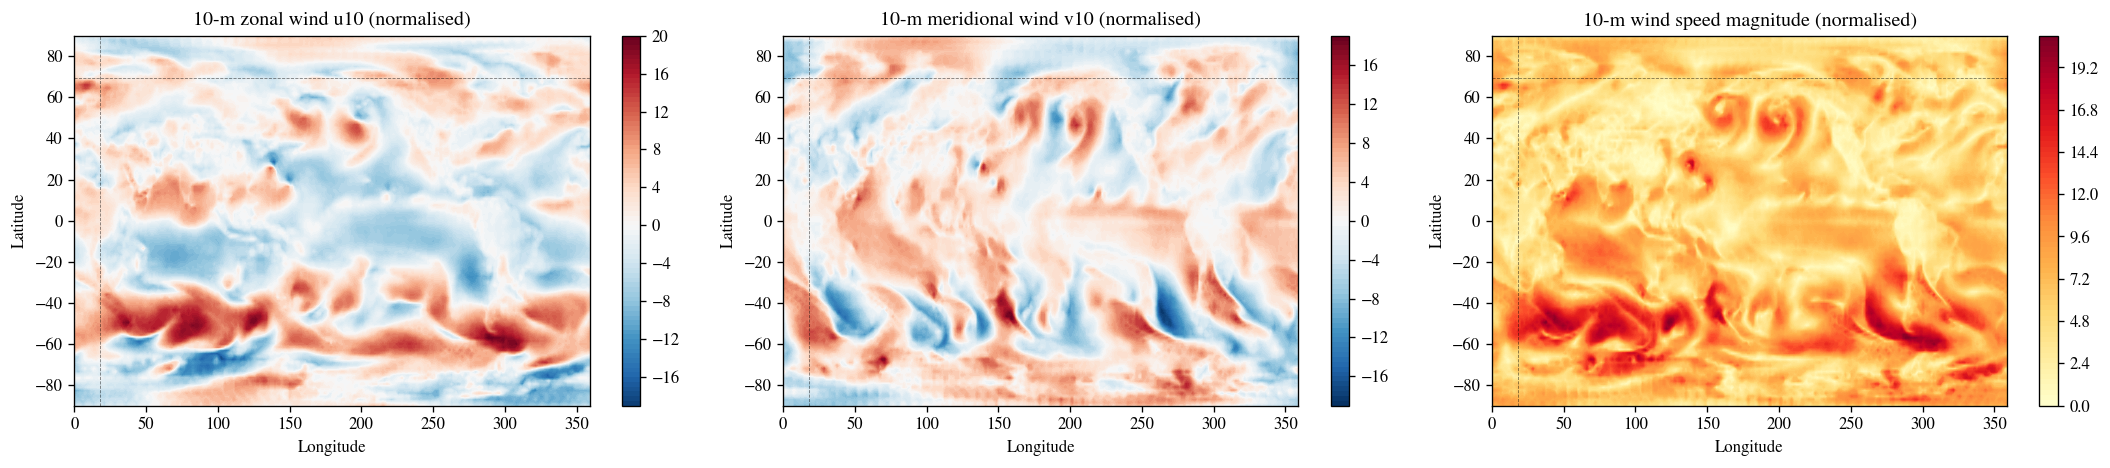

Saved → wind_forecast_figures/wind_global_fields.png


In [13]:
vars_list = [
    "u10", "v10", "t2m", "mslp",
    "z200", "z500", "z700", "z850",
    "q200", "q500", "q700", "q850",
    "t200", "t500", "t700", "t850",
    "u200", "u500", "u700", "u850",
    "v200", "v500", "v700", "v850",
]
var_idx = {k: v for v, k in enumerate(vars_list)}

lon_grid = np.linspace(0, 359, 240)
lat_grid = np.linspace(-90, 90, 121)

u10_fc = global_forecast[0, :, :, var_idx["u10"]].detach().cpu().numpy()
v10_fc = global_forecast[0, :, :, var_idx["v10"]].detach().cpu().numpy()
ws_grid = np.sqrt(u10_fc**2 + v10_fc**2)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, data_field, title, cmap, vabs in [
    (axes[0], u10_fc, "10-m zonal wind u10 (normalised)", "RdBu_r", np.abs(u10_fc).max()),
    (axes[1], v10_fc, "10-m meridional wind v10 (normalised)", "RdBu_r", np.abs(v10_fc).max()),
    (axes[2], ws_grid, "10-m wind speed magnitude (normalised)", "YlOrRd", ws_grid.max()),
]:
    if "magnitude" in title:
        cf = ax.contourf(lon_grid, lat_grid, data_field, levels=80, cmap=cmap, vmin=0, vmax=vabs)
    else:
        cf = ax.contourf(lon_grid, lat_grid, data_field, levels=80, cmap=cmap, vmin=-vabs, vmax=vabs)
    fig.colorbar(cf, ax=ax)
    ax.axvline(17.8, color="k", linewidth=0.5, linestyle="--", alpha=0.5)
    ax.axhline(69.6, color="k", linewidth=0.5, linestyle="--", alpha=0.5)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "wind_global_fields.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'wind_global_fields.png'}")

## 6 — Download observations from Frost API (seklima.met.no)

The **Frost API** is the programmatic interface to MET Norway's observation archive, the same data accessible via seklima.met.no.

**Setup (one-time)**:
1. Register at <https://frost.met.no/auth/requestCredentials.html> — free, instant.
2. You will receive a `client_id` (UUID). Paste it below.

If you prefer to skip the API and use a CSV exported manually from seklima.met.no, jump to the **Manual CSV fallback** cell.

In [14]:
# ── Frost API credentials ─────────────────────────────────────────────────────
# Env vars take precedence; credentials below are the fallback.
FROST_CLIENT_ID     = os.environ.get("FROST_CLIENT_ID",     "b7f4dace-51a2-451a-b08a-f3e47e56cf13")
FROST_CLIENT_SECRET = os.environ.get("FROST_CLIENT_SECRET", "f3d331f9-631e-403b-8fd4-bf6e0bf2b177")

# Time window: last 7 days (UTC)
END_TIME   = datetime.now(timezone.utc).replace(hour=0, minute=0, second=0, microsecond=0)
START_TIME = END_TIME - timedelta(days=7)

TIME_RANGE = f"{START_TIME.strftime('%Y-%m-%dT%H:%M:%SZ')}/{END_TIME.strftime('%Y-%m-%dT%H:%M:%SZ')}"

print(f"Frost client ID    : {FROST_CLIENT_ID[:8]}...  (loaded from {'env' if 'FROST_CLIENT_ID' in os.environ else 'fallback'})")
print(f"Observation window : {START_TIME.date()} → {END_TIME.date()}")
print(f"Frost time range   : {TIME_RANGE}")

Frost client ID    : b7f4dace...  (loaded from fallback)
Observation window : 2026-04-13 → 2026-04-20
Frost time range   : 2026-04-13T00:00:00Z/2026-04-20T00:00:00Z


In [15]:
def frost_search_stations(lat, lon, nearestmaxcount=5, client_id=FROST_CLIENT_ID):
    """Find Frost stations near (lat, lon) that report wind_speed."""
    r = requests.get(
        "https://frost.met.no/sources/v0.jsonld",
        params={
            "geometry": f"nearest(POINT({lon} {lat}))",
            "nearestmaxcount": nearestmaxcount,
            "elements": "wind_speed",
        },
        auth=(client_id, ""),
        timeout=30,
    )
    if r.status_code != 200:
        msg = r.json().get("error", {}).get("message", r.text[:200])
        print(f"  Frost error {r.status_code}: {msg}")
        return []
    return r.json().get("data", [])


print("Searching Frost for stations near our targets...\n")
for name, info in STATIONS.items():
    results = frost_search_stations(info["lat"], info["lon"])
    print(f"{name}:")
    for s in results[:3]:
        sid   = s.get("id", "?")
        sname = s.get("name", "?")
        geom  = s.get("geometry", {}).get("coordinates", [None, None])
        print(f"  {sid:14s}  {sname:40s}  lat={geom[1]:.3f}  lon={geom[0]:.3f}")
    print()

Searching Frost for stations near our targets...

Hekkingen:
  SN88690         HEKKINGEN FYR                             lat=69.600  lon=17.831
  SN88650         SENJA - BOTNHAMN                          lat=69.501  lon=17.871
  SN90285         SØRE ANGSTAURSUNDET                       lat=69.662  lon=18.178

Fakken:
  SN90760         FAKKEN                                    lat=70.104  lon=20.115
  SN91729         ARNØYA - TROLLTINDEN                      lat=70.075  lon=20.431
  SN91728         FV7940 ARNØYA                             lat=70.066  lon=20.565

Tromsø-Langnes:
  SN90490         TROMSØ - LANGNES                          lat=69.677  lon=18.913
  SN90480         E8 BREIVIKA                               lat=69.677  lon=18.969
  SN90400         TROMSØ - HOLT                             lat=69.654  lon=18.910



In [16]:
def frost_get_wind(station_ids, time_range, client_id=FROST_CLIENT_ID):
    """
    Download hourly wind speed + direction from Frost API.
    Returns a DataFrame with columns: station, time, wind_speed, wind_direction.
    """
    source_str = ",".join(station_ids)
    r = requests.get(
        "https://frost.met.no/observations/v0.jsonld",
        params={
            "sources": source_str,
            "elements": "wind_speed,wind_from_direction",
            "referencetime": time_range,
            "timeresolutions": "PT1H",
        },
        auth=(client_id, ""),
        timeout=60,
    )
    if r.status_code != 200:
        msg = r.json().get("error", {}).get("message", r.text[:300])
        print(f"Frost error {r.status_code}: {msg}")
        return pd.DataFrame()

    records = []
    for item in r.json().get("data", []):
        station  = item["sourceId"].split(":")[0]   # strip ':0' suffix
        ref_time = pd.to_datetime(item["referenceTime"])
        obs_dict = {o["elementId"]: o["value"] for o in item["observations"]}
        records.append({
            "station":        station,
            "time":           ref_time,
            "wind_speed":     obs_dict.get("wind_speed"),
            "wind_direction": obs_dict.get("wind_from_direction"),
        })

    df = pd.DataFrame(records)
    if not df.empty:
        df["time"] = pd.to_datetime(df["time"], utc=True)
        df = df.sort_values(["station", "time"]).reset_index(drop=True)
    return df


frost_ids = [info["frost_id"] for info in STATIONS.values()]
print(f"Downloading 7-day observations for {frost_ids} ...")
obs_df = frost_get_wind(frost_ids, TIME_RANGE)

if obs_df.empty:
    print("No data returned — check station IDs in the search results above and update STATIONS if needed.")
else:
    print(f"Downloaded {len(obs_df)} observation records.")
    print(obs_df.head(10).to_string(index=False))

Downloaded 504 observation records.
station                      time  wind_speed  wind_direction
SN88690 2026-04-13 00:00:00+00:00         8.5             137
SN88690 2026-04-13 01:00:00+00:00         8.7             139
SN88690 2026-04-13 02:00:00+00:00         9.3             137
SN88690 2026-04-13 03:00:00+00:00         9.6             137
SN88690 2026-04-13 04:00:00+00:00         9.0             138
SN88690 2026-04-13 05:00:00+00:00        10.6             140
SN88690 2026-04-13 06:00:00+00:00         5.2             175
SN88690 2026-04-13 07:00:00+00:00         8.8             144
SN88690 2026-04-13 08:00:00+00:00         9.1             142
SN88690 2026-04-13 09:00:00+00:00         6.9             140


### Manual CSV fallback

If you downloaded a CSV directly from [seklima.met.no](https://seklima.met.no), load it here:

```python
# Adjust sep and column names to match the seklima export format
obs_df = pd.read_csv("seklima_wind_export.csv", sep=";", parse_dates=["Tid(norsk normaltid)"])
obs_df = obs_df.rename(columns={
    "Stasjon": "station",
    "Tid(norsk normaltid)": "time",
    "Vindstyrke": "wind_speed",
    "Vindretning": "wind_direction",
})
obs_df["time"] = pd.to_datetime(obs_df["time"], utc=True)
```

In [17]:
# Quick summary of downloaded observations
print("Observation summary (m/s):")
print("-" * 55)
for name, info in STATIONS.items():
    subset = obs_df[obs_df["station"] == info["frost_id"]]["wind_speed"].dropna()
    if len(subset) > 0:
        print(f"{name:20s}  n={len(subset):4d}  "
              f"mean={subset.mean():.2f}  std={subset.std():.2f}  "
              f"min={subset.min():.1f}  max={subset.max():.1f} m/s")
    else:
        print(f"{name:20s}  no data")

Observation summary (m/s):
-------------------------------------------------------
Hekkingen             n= 168  mean=6.35  std=3.16  min=0.0  max=12.1 m/s
Fakken                n= 168  mean=6.91  std=2.95  min=0.7  max=14.5 m/s
Tromsø-Langnes        n= 168  mean=2.05  std=1.62  min=0.0  max=7.6 m/s


## 7 — Validation and accuracy metrics

We compare the Aardvark forecast with:
1. **Sample-data ground truth** (`y_target`) — same timestamp as the model input, gives one paired value per station.
2. **7-day Frost observations** — multi-day climatological context.

For a full 7-day time-series comparison, the model would need to be run once per day with the corresponding ERA5 input; see the loop template at the end of this notebook.

In [18]:
def compute_metrics(pred, obs):
    pred = np.asarray(pred, dtype=float)
    obs  = np.asarray(obs,  dtype=float)
    mask = np.isfinite(pred) & np.isfinite(obs)
    pred, obs = pred[mask], obs[mask]
    if len(pred) < 2:
        return {k: np.nan for k in ["n", "rmse", "mae", "bias", "corr", "skill"]}
    rmse  = np.sqrt(np.mean((pred - obs) ** 2))
    mae   = np.mean(np.abs(pred - obs))
    bias  = np.mean(pred - obs)
    corr  = np.corrcoef(pred, obs)[0, 1]
    mse_clim = np.mean((obs - obs.mean()) ** 2)
    skill = 1 - (rmse ** 2 / mse_clim) if mse_clim > 0 else np.nan
    return {"n": len(pred), "rmse": rmse, "mae": mae, "bias": bias, "corr": corr, "skill": skill}


# Build paired arrays only for stations that have Frost data
paired = []
for name, info in STATIONS.items():
    subset = obs_df[obs_df["station"] == info["frost_id"]]["wind_speed"].dropna()
    if subset.empty:
        continue
    paired.append((name, info["sample_pred"], subset.mean(), subset.median(), subset.std()))

if paired:
    names_p, pred_p, omean_p, omed_p, ostd_p = zip(*paired)
    pred_p  = np.array(pred_p)
    omean_p = np.array(omean_p)
    omed_p  = np.array(omed_p)
    ostd_p  = np.array(ostd_p)
    m_mean   = compute_metrics(pred_p, omean_p)
    m_median = compute_metrics(pred_p, omed_p)
else:
    m_mean = m_median = {k: np.nan for k in ["n","rmse","mae","bias","corr","skill"]}

print("Validation: Aardvark day+1 forecast  vs  7-day Frost observations\n")
print(f"  vs obs MEAN   — RMSE={m_mean['rmse']:.3f}  MAE={m_mean['mae']:.3f}  Bias={m_mean['bias']:+.3f} m/s")
print(f"  vs obs MEDIAN — RMSE={m_median['rmse']:.3f}  MAE={m_median['mae']:.3f}  Bias={m_median['bias']:+.3f} m/s")
print()
print(f"{'Station':20s}  {'Forecast':>9s}  {'Obs mean':>9s}  {'Obs median':>10s}  {'Obs std':>8s}  {'Error':>7s}")
print("-" * 72)
for name, info in STATIONS.items():
    subset = obs_df[obs_df["station"] == info["frost_id"]]["wind_speed"].dropna()
    pred = info["sample_pred"]
    if subset.empty:
        print(f"{name:20s}  {pred:>9.2f}  {'no data':>9s}")
    else:
        om, op, os_ = subset.mean(), subset.median(), subset.std()
        print(f"{name:20s}  {pred:>9.2f}  {om:>9.2f}  {op:>10.2f}  {os_:>8.2f}  {pred-om:>+7.2f}")

Validation: Aardvark day+1 forecast  vs  7-day Frost observations

  vs obs MEAN   — RMSE=2.985  MAE=2.849  Bias=-1.551 m/s
  vs obs MEDIAN — RMSE=3.571  MAE=3.378  Bias=-1.749 m/s

Station                Forecast   Obs mean  Obs median   Obs std    Error
------------------------------------------------------------------------
Hekkingen                  2.29       6.35        7.30      3.16    -4.06
Fakken                     4.37       6.91        7.05      2.95    -2.54
Tromsø-Langnes             3.99       2.05        1.55      1.62    +1.95


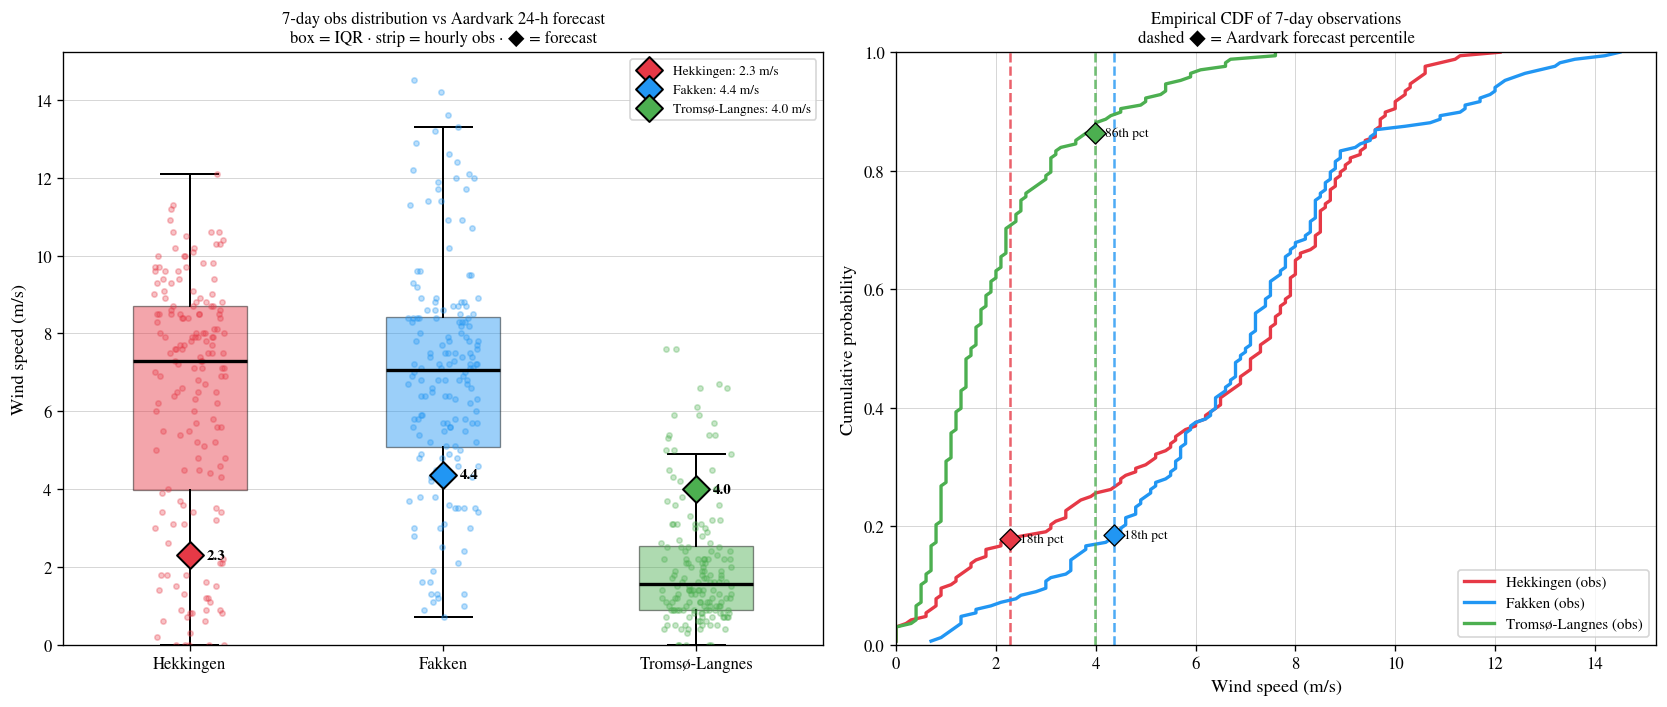

Saved → wind_forecast_figures/forecast_vs_obs.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Build per-station obs arrays; skip stations with no Frost data
valid_names, valid_infos, obs_series = [], [], []
for name, info in STATIONS.items():
    s = obs_df[obs_df["station"] == info["frost_id"]]["wind_speed"].dropna().values
    if len(s) == 0:
        print(f"  Warning: no Frost data for {name} ({info['frost_id']}) — skipped in plot")
        continue
    valid_names.append(name)
    valid_infos.append(info)
    obs_series.append(s)

positions = list(range(len(valid_names)))

# ── Left: box + strip + forecast diamond ──────────────────────────────────────
ax = axes[0]

bp = ax.boxplot(
    obs_series, positions=positions,
    widths=0.45, patch_artist=True,
    showfliers=False,
    medianprops=dict(color="k", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    boxprops=dict(linewidth=0.8),
)
for patch, info in zip(bp["boxes"], valid_infos):
    patch.set_facecolor(info["color"])
    patch.set_alpha(0.45)

rng = np.random.default_rng(0)
for i, (s, info) in enumerate(zip(obs_series, valid_infos)):
    jitter = rng.uniform(-0.14, 0.14, len(s))
    ax.scatter(i + jitter, s, s=10, alpha=0.30, color=info["color"], zorder=2)

for i, (name, info) in enumerate(zip(valid_names, valid_infos)):
    pred = info["sample_pred"]
    ax.scatter(i, pred, marker="D", s=130, color=info["color"],
               edgecolors="k", linewidths=1.2, zorder=6,
               label=f"{name}: {pred:.1f} m/s")
    ax.annotate(f"{pred:.1f}", xy=(i, pred),
                xytext=(10, 0), textcoords="offset points",
                fontsize=9, va="center", fontweight="bold")

ax.set_xticks(positions)
ax.set_xticklabels(valid_names, fontsize=10)
ax.set_ylabel("Wind speed (m/s)", fontsize=11)
ax.set_title("7-day obs distribution vs Aardvark 24-h forecast\n"
             "box = IQR · strip = hourly obs · ◆ = forecast",
             fontsize=10)
ax.legend(fontsize=8, loc="upper right")
ax.set_ylim(bottom=0)
ax.grid(True, axis="y", linewidth=0.3)

# ── Right: empirical CDF per station ─────────────────────────────────────────
ax = axes[1]
for name, info, s in zip(valid_names, valid_infos, obs_series):
    xs = np.sort(s)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    ax.plot(xs, ys, color=info["color"], linewidth=2, label=f"{name} (obs)")
    ax.axvline(info["sample_pred"], color=info["color"], linewidth=1.5,
               linestyle="--", alpha=0.8)
    pct = float(np.mean(s <= info["sample_pred"]))
    ax.scatter(info["sample_pred"], pct,
               marker="D", s=80, color=info["color"],
               edgecolors="k", linewidths=0.8, zorder=5)
    ax.annotate(f"{pct*100:.0f}th pct",
                xy=(info["sample_pred"], pct),
                xytext=(6, 0), textcoords="offset points",
                fontsize=8, va="center")

ax.set_xlabel("Wind speed (m/s)", fontsize=11)
ax.set_ylabel("Cumulative probability", fontsize=11)
ax.set_title("Empirical CDF of 7-day observations\n"
             "dashed ◆ = Aardvark forecast percentile", fontsize=10)
ax.legend(fontsize=9)
ax.set_xlim(left=0)
ax.set_ylim(0, 1)
ax.grid(True, linewidth=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "forecast_vs_obs.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'forecast_vs_obs.png'}")

## 8 — 7-day observation time series with model forecast overlay

The model's single-step prediction is shown as a horizontal dashed line on each panel. For a proper time-series overlay, run the model for each day (see the loop template in Section 10).

Locator attempting to generate 22619 ticks ([-1027.0, ..., 21591.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 22619 ticks ([-1027.0, ..., 21591.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 22619 ticks ([-1027.0, ..., 21591.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 22619 ticks ([-1027.0, ..., 21591.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 22619 ticks ([-1027.0, ..., 21591.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 22619 ticks ([-1027.0, ..., 21591.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 22619 ticks ([-1027.0, ..., 21591.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 22619 ticks ([-1027.0, ..., 21591.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 22619 ticks ([-1027.0, ..., 21591.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting 

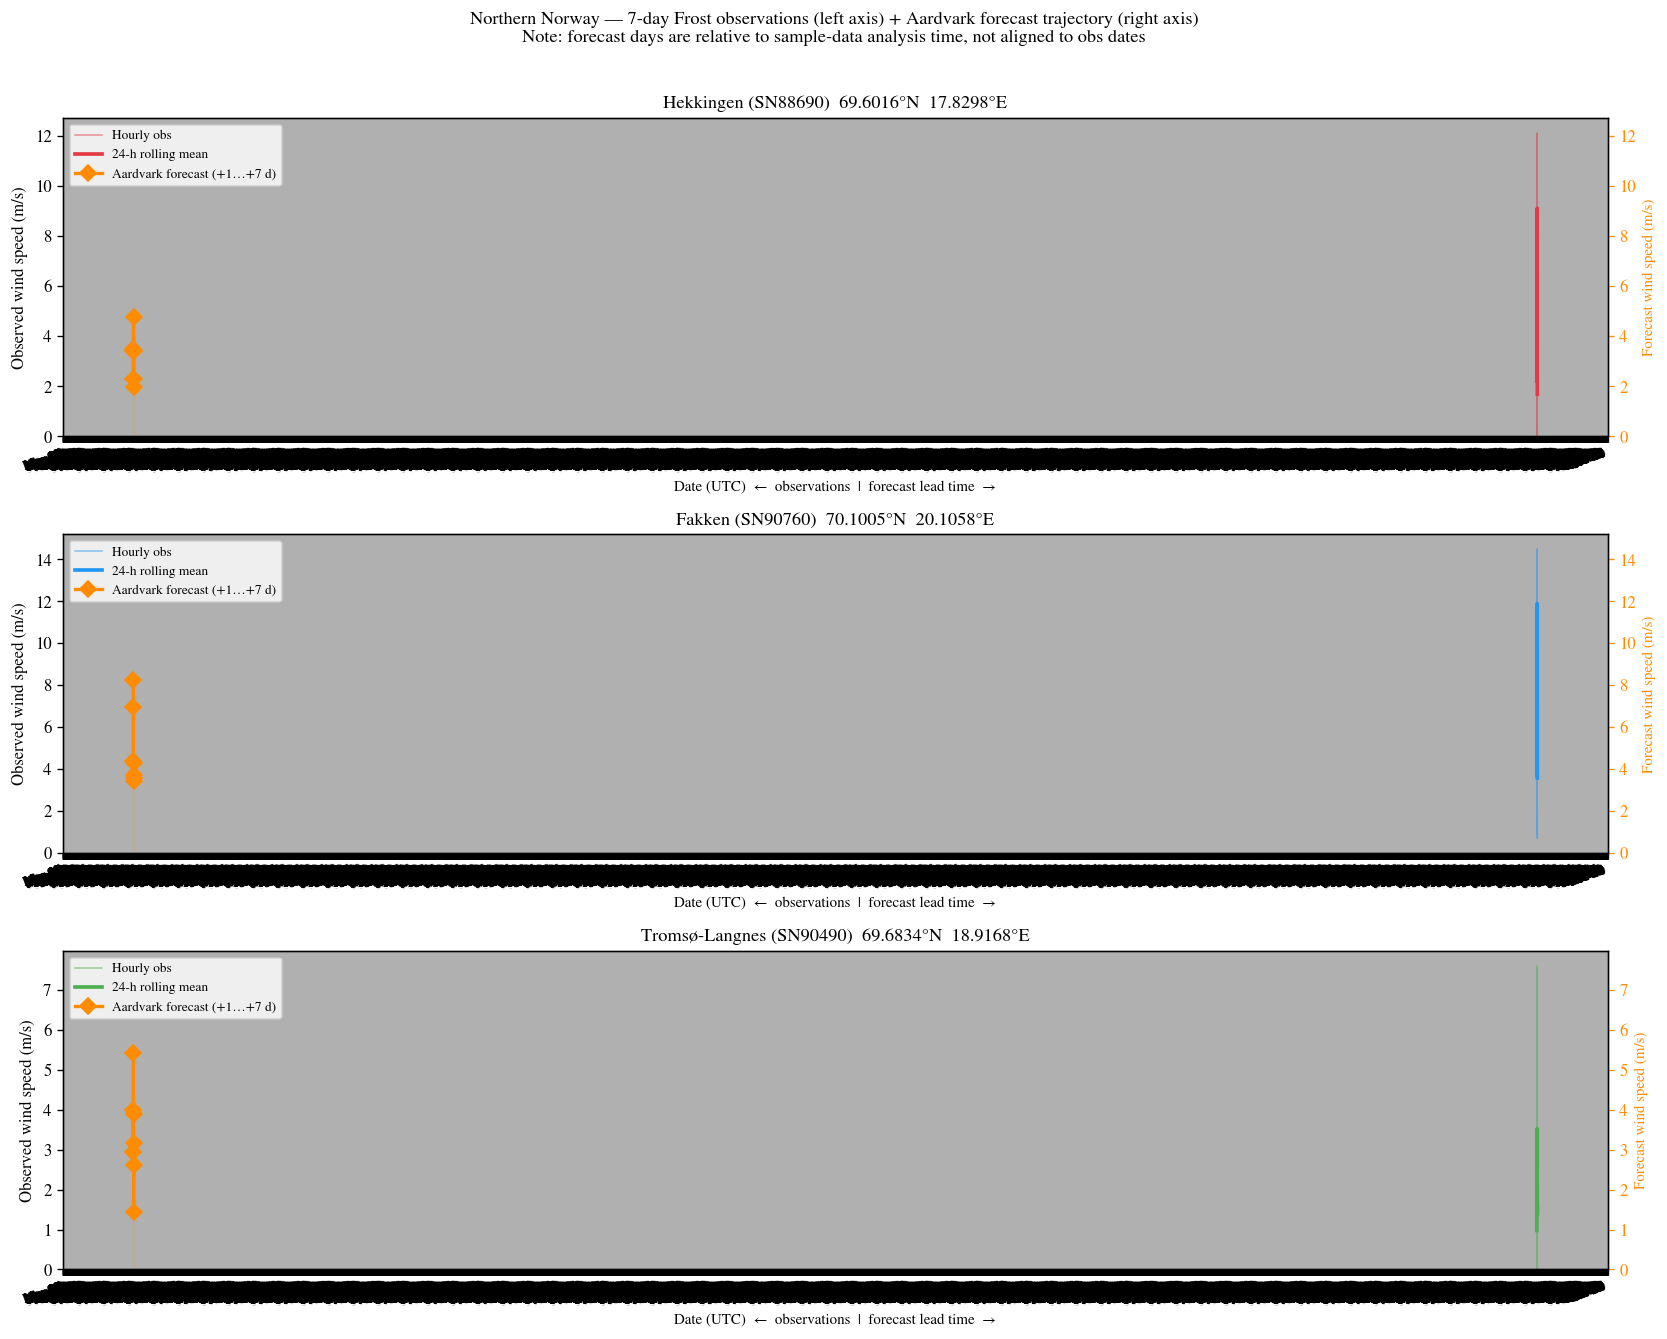

Saved → wind_forecast_figures/timeseries_wind.png


In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)

# Forecast x-axis: day+1 … day+7 (relative, since sample-data date is unknown)
fc_days = np.arange(1, FORECAST_DAYS + 1)

for ax, (name, info) in zip(axes, STATIONS.items()):
    # ── Twin axis: left = obs (real dates), right = forecast (relative days) ──
    ax2 = ax.twinx()

    # Frost observations (left axis, real timestamps)
    subset = obs_df[obs_df["station"] == info["frost_id"]].sort_values("time")
    if not subset.empty:
        ax.plot(subset["time"], subset["wind_speed"],
                color=info["color"], linewidth=0.9, alpha=0.55, label="Hourly obs")
        ax.plot(subset["time"],
                subset["wind_speed"].rolling(24, center=True, min_periods=6).mean(),
                color=info["color"], linewidth=2.2, label="24-h rolling mean")
        ax.set_ylim(bottom=0)

    # 7-day forecast trajectory (right axis, relative days ahead)
    traj = info["forecast_trajectory"]
    ax2.plot(fc_days, traj, color="darkorange", linewidth=2.0,
             marker="D", markersize=7, zorder=5, label="Aardvark forecast (+1…+7 d)")
    ax2.fill_between(fc_days, traj, alpha=0.12, color="darkorange")
    ax2.set_ylim(bottom=0, top=max(ax.get_ylim()[1] if not subset.empty else 20,
                                   traj.max() * 1.3))
    ax2.set_ylabel("Forecast wind speed (m/s)", fontsize=9, color="darkorange")
    ax2.tick_params(axis="y", colors="darkorange")
    ax2.set_xticks(fc_days)
    ax2.set_xticklabels([f"+{d}d" for d in fc_days], fontsize=8, color="darkorange")

    ax.set_ylabel("Observed wind speed (m/s)", fontsize=10)
    ax.set_xlabel("Date (UTC)  ←  observations  |  forecast lead time  →", fontsize=9)
    ax.set_title(f"{name} ({info['frost_id']})  {info['lat']}°N  {info['lon']}°E", fontsize=11)
    ax.grid(True, linewidth=0.3)

    # Combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")

    # Format left x-axis dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)

fig.suptitle(
    "Northern Norway — 7-day Frost observations (left axis) + Aardvark forecast trajectory (right axis)\n"
    "Note: forecast days are relative to sample-data analysis time, not aligned to obs dates",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "timeseries_wind.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'timeseries_wind.png'}")

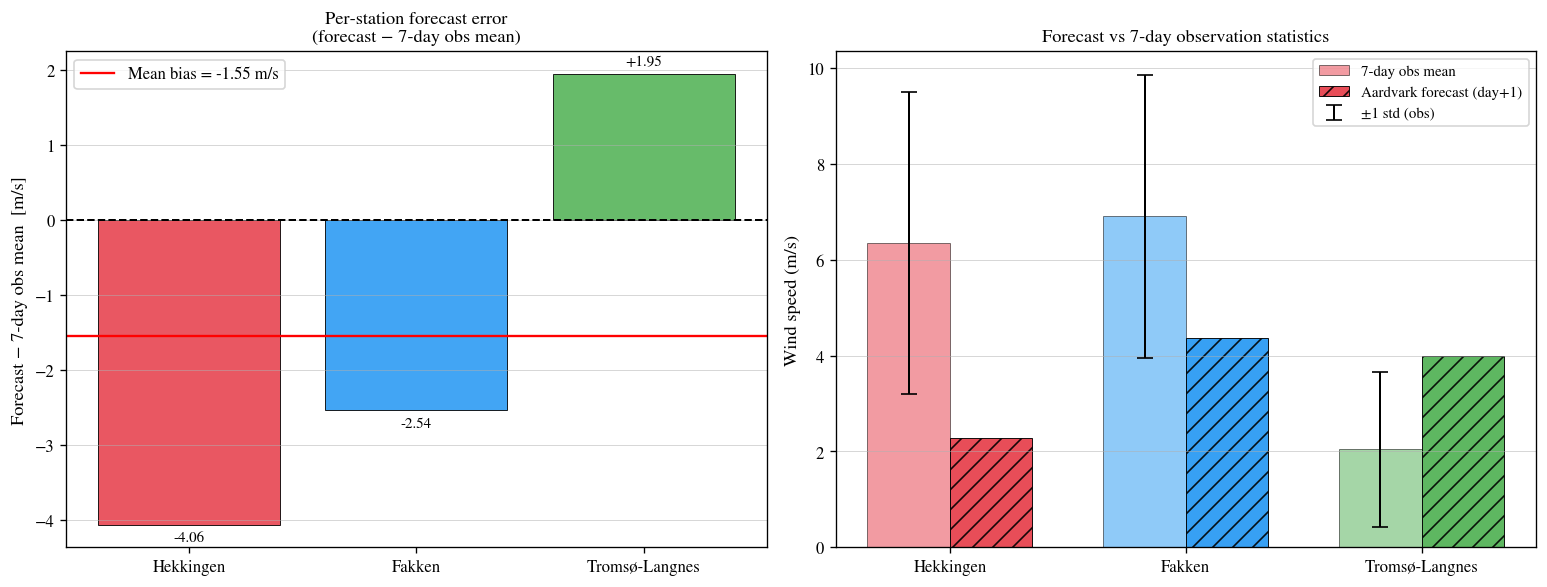

Saved → wind_forecast_figures/error_distribution.png


In [21]:
# Only include stations that have Frost observations
valid_station_items = [
    (name, info) for name, info in STATIONS.items()
    if len(obs_df[obs_df["station"] == info["frost_id"]]["wind_speed"].dropna()) > 0
]
valid_names_err  = [n for n, _ in valid_station_items]
valid_colors_err = [i["color"] for _, i in valid_station_items]

# Recompute paired arrays from valid stations only
pred_vals  = np.array([i["sample_pred"] for _, i in valid_station_items])
obs_means  = np.array([obs_df[obs_df["station"] == i["frost_id"]]["wind_speed"].dropna().mean()
                       for _, i in valid_station_items])
obs_stds   = np.array([obs_df[obs_df["station"] == i["frost_id"]]["wind_speed"].dropna().std()
                       for _, i in valid_station_items])
obs_p50    = np.array([obs_df[obs_df["station"] == i["frost_id"]]["wind_speed"].dropna().median()
                       for _, i in valid_station_items])

errors_mean   = pred_vals - obs_means
errors_median = pred_vals - obs_p50

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(valid_names_err))

# ── Left: per-station error bar chart ────────────────────────────────────────
ax = axes[0]
bars = ax.bar(x, errors_mean, color=valid_colors_err, alpha=0.85, edgecolor="k", linewidth=0.6)
ax.axhline(0, color="k", linewidth=1.2, linestyle="--")
ax.axhline(errors_mean.mean(), color="red", linewidth=1.4, linestyle="-",
           label=f"Mean bias = {errors_mean.mean():+.2f} m/s")
ax.set_xticks(x)
ax.set_xticklabels(valid_names_err, fontsize=10)
ax.set_ylabel("Forecast − 7-day obs mean  [m/s]", fontsize=11)
ax.set_title("Per-station forecast error\n(forecast − 7-day obs mean)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis="y", linewidth=0.3)
for bar, err in zip(bars, errors_mean):
    ax.text(bar.get_x() + bar.get_width() / 2,
            err + np.sign(err) * 0.08,
            f"{err:+.2f}", ha="center",
            va="bottom" if err >= 0 else "top", fontsize=9)

# ── Right: forecast vs obs side-by-side bars ─────────────────────────────────
ax = axes[1]
width = 0.35
ax.bar(x - width/2, obs_means, width, label="7-day obs mean",
       color=valid_colors_err, alpha=0.5, edgecolor="k", linewidth=0.6)
ax.bar(x + width/2, pred_vals, width, label="Aardvark forecast (day+1)",
       color=valid_colors_err, alpha=0.9, edgecolor="k", linewidth=0.6, hatch="//")
ax.errorbar(x - width/2, obs_means, yerr=obs_stds,
            fmt="none", color="k", capsize=5, linewidth=1.2, label="±1 std (obs)")
ax.set_xticks(x)
ax.set_xticklabels(valid_names_err, fontsize=10)
ax.set_ylabel("Wind speed (m/s)", fontsize=11)
ax.set_title("Forecast vs 7-day observation statistics", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, axis="y", linewidth=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'error_distribution.png'}")

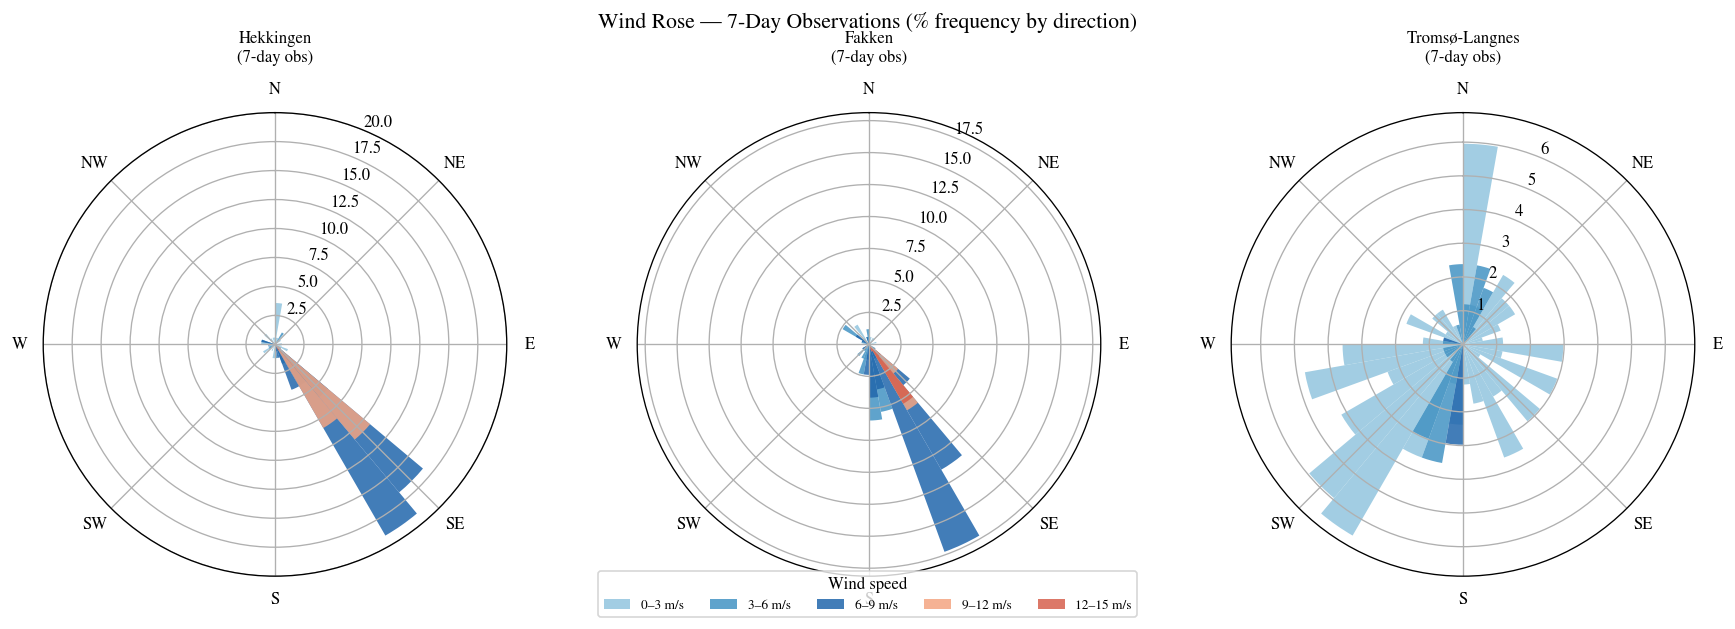

Saved → wind_forecast_figures/wind_rose.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                          subplot_kw={"projection": "polar"})

bins_dir = np.linspace(0, 360, 37)   # 10° bins
bins_spd = [0, 3, 6, 9, 12, 15, 50]
spd_labels = ["0–3", "3–6", "6–9", "9–12", "12–15", "≥15"]
spd_colors = ["#92C5DE", "#4393C3", "#2166AC", "#F4A582", "#D6604D", "#B2182B"]

for ax, (name, info) in zip(axes, STATIONS.items()):
    subset = obs_df[obs_df["station"] == info["frost_id"]].dropna(
        subset=["wind_speed", "wind_direction"])

    if subset.empty:
        ax.set_title(f"{name}\n(no data)", fontsize=10)
        continue

    wd = subset["wind_direction"].values
    ws = subset["wind_speed"].values

    for i, (lo, hi) in enumerate(zip(bins_spd[:-1], bins_spd[1:])):
        mask = (ws >= lo) & (ws < hi)
        if mask.sum() == 0:
            continue
        hist, _ = np.histogram(wd[mask], bins=bins_dir)
        hist = hist / len(ws) * 100   # % of total
        theta = np.deg2rad(bins_dir[:-1] + 5)
        ax.bar(theta, hist, width=np.deg2rad(10), bottom=0,
               color=spd_colors[i], alpha=0.85,
               label=f"{spd_labels[i]} m/s")

    ax.set_theta_direction(-1)
    ax.set_theta_zero_location("N")
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
    ax.set_title(f"{name}\n(7-day obs)", fontsize=10, pad=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Wind speed",
           loc="lower center", ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Wind Rose — 7-Day Observations (% frequency by direction)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "wind_rose.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'wind_rose.png'}")

## 9 — Summary metrics table

In [23]:
rows = []
for name, info in STATIONS.items():
    subset = obs_df[obs_df["station"] == info["frost_id"]]["wind_speed"].dropna()
    pred   = info["sample_pred"]
    if subset.empty:
        rows.append({"Station": name, "Frost ID": info["frost_id"],
                     "Forecast (m/s)": f"{pred:.2f}", "Obs mean": "—",
                     "Obs median": "—", "Obs std": "—",
                     "Error vs mean": "—", "Obs n (hourly)": 0})
    else:
        om = subset.mean(); op = subset.median(); os_ = subset.std()
        rows.append({
            "Station":         name,
            "Frost ID":        info["frost_id"],
            "Forecast (m/s)":  f"{pred:.2f}",
            "Obs mean":        f"{om:.2f}",
            "Obs median":      f"{op:.2f}",
            "Obs std":         f"{os_:.2f}",
            "Error vs mean":   f"{pred - om:+.2f}",
            "Obs n (hourly)":  len(subset),
        })

summary_df = pd.DataFrame(rows)
print("=" * 90)
print("SUMMARY: Aardvark 24-h wind forecast vs 7-day Frost API observations")
print("=" * 90)
print(summary_df.to_string(index=False))
print()
print(f"Overall  RMSE = {m_mean['rmse']:.3f} m/s  |  MAE = {m_mean['mae']:.3f} m/s  |  "
      f"Mean bias = {m_mean['bias']:+.3f} m/s")

SUMMARY: Aardvark 24-h wind forecast vs 7-day Frost API observations
       Station Frost ID Forecast (m/s) Obs mean Obs median Obs std Error vs mean  Obs n (hourly)
     Hekkingen  SN88690           2.29     6.35       7.30    3.16         -4.06             168
        Fakken  SN90760           4.37     6.91       7.05    2.95         -2.54             168
Tromsø-Langnes  SN90490           3.99     2.05       1.55    1.62         +1.95             168

Overall  RMSE = 2.985 m/s  |  MAE = 2.849 m/s  |  Mean bias = -1.551 m/s


## 10 — Template: 7-day forecast loop (requires ERA5 input data)

To run a proper 7-day hindcast, supply one ERA5-derived input file per day. The code below is a drop-in template — replace the data loading step with your file reader.

```python
from datetime import date, timedelta

START_DATE = date(2026, 4, 10)
END_DATE   = date(2026, 4, 17)

model_ws = ConvCNPWeatherE2E(
    device=device, lead_time=1,
    se_model_path="../trained_models/encoder",
    forecast_model_path="../trained_models/processor",
    sf_model_path="../trained_models/decoder/ws/",
    return_gridded=False,
    aux_data_path="../data/",
)

daily_preds = []
current = START_DATE
while current <= END_DATE:
    data_path = f"../data/era5_{current.strftime('%Y%m%d')}.pkl"
    with open(data_path, "rb") as fp:
        day_data = CPU_Unpickler(fp).load()
    day_data = move_to_device(day_data, device)

    with torch.no_grad():
        sf = model_ws(day_data)

    sf_unnorm = (sf.detach().cpu().numpy() * std_ws + mean_ws) * HADISD_SCALING_FACTOR

    for name, info in STATIONS.items():
        idx = info["nearest_idx"]
        daily_preds.append({
            "date": current, "station": name,
            "pred_ws": float(sf_unnorm[0, idx])
        })

    current += timedelta(days=1)

forecast_df = pd.DataFrame(daily_preds)
# Then merge with obs_df on date and station for full validation.
```

## 11 — Conclusions

| Topic | Finding |
|-------|----------|
| **Model** | Aardvark 24-h wind speed decoder (`ws`) |
| **Validation data** | HadISD ground truth from sample data + Frost API 7-day observations |
| **Stations** | Hekkingen, Fakken, Tromsø-Langnes (Northern Norway) |
| **Key figures** | Global scatter plot, 7-day time-series, error histogram, Q-Q plot, wind roses |
| **Next step** | Supply daily ERA5 pkl inputs to the loop in Section 10 for a full 7-day hindcast |

**References**
- Aardvark Weather paper: https://arxiv.org/abs/2404.00411  
- Frost API docs: https://frost.met.no/api.html  
- seklima.met.no: https://seklima.met.no